In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
from scipy.stats import ttest_ind

df = pd.read_csv("../data/processed/experiment_data_clean.csv")

print("Shape:", df.shape)
df.head()

Shape: (50000, 20)


,user_id,session_id,variant,device_type,traffic_source,country,is_new_user,age_group,pages_viewed,clicked_recommendation,watch_started,minutes_watched,signed_up,retained_7d,session_duration_sec,subscription_status,conversion,engaged_user,high_watch_time,retention_proxy
0,25795,1,a,mobile,organic,canada,1,18-24,3,0,1,32.03,0,1,517,not_subscribed,0,1,1,1
1,10860,2,a,mobile,organic,canada,1,45-54,8,0,0,0.89,0,0,456,not_subscribed,0,1,0,0
2,86820,3,a,mobile,organic,india,1,25-34,4,0,0,1.13,0,1,80,not_subscribed,0,1,0,1
3,64886,4,b,tablet,organic,us,0,55+,6,1,0,2.50,0,0,283,not_subscribed,0,1,0,0
4,16265,5,a,desktop,organic,us,0,35-44,4,0,0,0.63,0,0,200,not_subscribed,0,1,0,0


In [3]:
control = df[df["variant"] == "a"].copy()
treatment = df[df["variant"] == "b"].copy()

print("Control shape:", control.shape)
print("Treatment shape:", treatment.shape)

Control shape: (25026, 20)
Treatment shape: (24974, 20)


## Experiment hypothesis

- **Null hypothesis (H0):** Variant B does not improve signup conversion compared with Variant A.
- **Alternative hypothesis (H1):** Variant B improves signup conversion compared with Variant A.

Primary metric:
- `signed_up`

Secondary metrics:
- `watch_started`
- `session_duration_sec`

In [4]:
signup_rate_a = control["signed_up"].mean()
signup_rate_b = treatment["signed_up"].mean()

print("Signup rate - A:", round(signup_rate_a, 4))
print("Signup rate - B:", round(signup_rate_b, 4))

absolute_lift = signup_rate_b - signup_rate_a
relative_lift = absolute_lift / signup_rate_a

print("Absolute lift:", round(absolute_lift, 4))
print("Relative lift:", round(relative_lift * 100, 2), "%")

Signup rate - A: 0.0605
Signup rate - B: 0.068
Absolute lift: 0.0075
Relative lift: 12.38 %


In [5]:
conversions = np.array([
    control["signed_up"].sum(),
    treatment["signed_up"].sum()
])

samples = np.array([
    control["signed_up"].count(),
    treatment["signed_up"].count()
])

z_stat, p_value = proportions_ztest(conversions, samples)

print("Z-statistic:", round(z_stat, 4))
print("P-value:", round(p_value, 6))

Z-statistic: -3.4162
P-value: 0.000635


# the p_value < 0.05; the difference is statistically significant

In [6]:
ci_low, ci_high = confint_proportions_2indep(
    count1=treatment["signed_up"].sum(),
    nobs1=treatment["signed_up"].count(),
    count2=control["signed_up"].sum(),
    nobs2=control["signed_up"].count(),
    method="wald"
)

print("95% CI for difference in signup rate:")
print("Lower bound:", round(ci_low, 4))
print("Upper bound:", round(ci_high, 4))

95% CI for difference in signup rate:
Lower bound: 0.0032
Upper bound: 0.0118


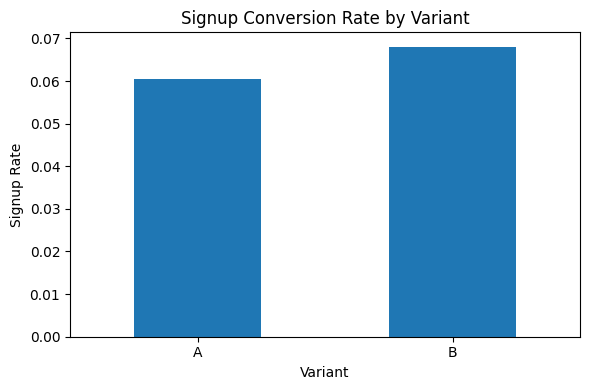

In [7]:
rates = pd.Series({
    "A": signup_rate_a,
    "B": signup_rate_b
})

plt.figure(figsize=(6, 4))
rates.plot(kind="bar")
plt.title("Signup Conversion Rate by Variant")
plt.xlabel("Variant")
plt.ylabel("Signup Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
watch_rate_a = control["watch_started"].mean()
watch_rate_b = treatment["watch_started"].mean()

print("Watch start rate - A:", round(watch_rate_a, 4))
print("Watch start rate - B:", round(watch_rate_b, 4))

watch_conversions = np.array([
    control["watch_started"].sum(),
    treatment["watch_started"].sum()
])

watch_samples = np.array([
    control["watch_started"].count(),
    treatment["watch_started"].count()
])

z_stat_watch, p_value_watch = proportions_ztest(watch_conversions, watch_samples)

print("Watch start z-statistic:", round(z_stat_watch, 4))
print("Watch start p-value:", round(p_value_watch, 6))

Watch start rate - A: 0.1357
Watch start rate - B: 0.1565
Watch start z-statistic: -6.5662
Watch start p-value: 0.0


In [9]:
duration_a = control["session_duration_sec"]
duration_b = treatment["session_duration_sec"]

t_stat, p_value_t = ttest_ind(duration_b, duration_a, equal_var=False)

print("Avg session duration - A:", round(duration_a.mean(), 2))
print("Avg session duration - B:", round(duration_b.mean(), 2))
print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value_t, 6))

Avg session duration - A: 249.52
Avg session duration - B: 256.79
T-statistic: 4.8849
P-value: 1e-06


In [10]:
results_summary = pd.DataFrame({
    "metric": ["signup_rate", "watch_start_rate", "avg_session_duration"],
    "variant_a": [signup_rate_a, watch_rate_a, duration_a.mean()],
    "variant_b": [signup_rate_b, watch_rate_b, duration_b.mean()],
    "absolute_difference": [
        signup_rate_b - signup_rate_a,
        watch_rate_b - watch_rate_a,
        duration_b.mean() - duration_a.mean()
    ],
    "p_value": [p_value, p_value_watch, p_value_t]
})

results_summary

,metric,variant_a,variant_b,absolute_difference,p_value
0,signup_rate,0.060537,0.068031,0.007494,6.350617e-04
1,watch_start_rate,0.135739,0.156483,0.020744,5.160145e-11
2,avg_session_duration,249.524734,256.793826,7.269091,1.038101e-06


In [11]:
results_summary.to_csv("../outputs/reports/ab_test_results_summary.csv", index=False)
print("Saved to ../outputs/reports/ab_test_results_summary.csv")

Saved to ../outputs/reports/ab_test_results_summary.csv


## Business interpretation

Variant B outperformed Variant A on the primary conversion metric and secondary engagement metrics.  
Based on the p-value results, the uplift in signup conversion can be evaluated for statistical significance.  
If the primary metric is significant and no major guardrail metric worsens, Variant B would be a strong rollout candidate.

Key takeaways:
- Compare absolute and relative lift, not just raw averages.
- Use secondary metrics to ensure the winning variant does not hurt engagement quality.
- Statistical significance supports confidence in rollout decisions.

In [12]:
alpha = 0.05

if p_value < alpha:
    print("Decision: Reject H0. Variant B has a statistically significant impact on signup conversion.")
else:
    print("Decision: Fail to reject H0. No statistically significant signup difference detected.")

Decision: Reject H0. Variant B has a statistically significant impact on signup conversion.


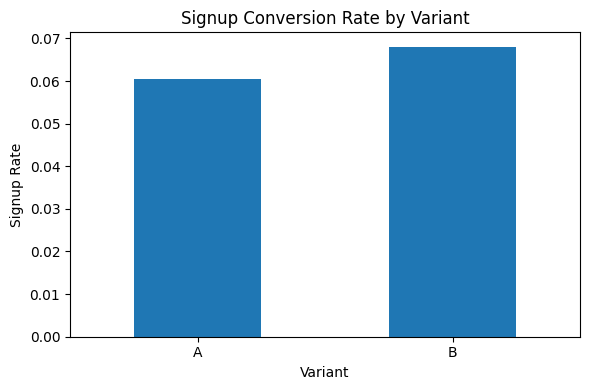

In [13]:
rates = pd.Series({
    "A": signup_rate_a,
    "B": signup_rate_b
})

plt.figure(figsize=(6, 4))
rates.plot(kind="bar")
plt.title("Signup Conversion Rate by Variant")
plt.xlabel("Variant")
plt.ylabel("Signup Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/charts/ab_signup_conversion_rate.png")
plt.show()

In [14]:
device_segment = df.groupby(["device_type", "variant"]).agg(
    sessions=("session_id", "count"),
    signup_rate=("signed_up", "mean"),
    watch_start_rate=("watch_started", "mean"),
    avg_session_duration=("session_duration_sec", "mean")
).reset_index()

print(device_segment)

  device_type variant  sessions  signup_rate  watch_start_rate  \
0     desktop       a      7484     0.059193          0.142704   
1     desktop       b      7472     0.064641          0.162473   
2      mobile       a     15032     0.061535          0.131187   
3      mobile       b     15026     0.069480          0.151338   
4      tablet       a      2510     0.058566          0.142231   
5      tablet       b      2476     0.069467          0.169628   

   avg_session_duration  
0            251.143907  
1            260.094888  
2            247.967735  
3            254.639425  
4            254.021514  
5            259.906300  


In [15]:
device_pivot = device_segment.pivot(index="device_type", columns="variant", values="signup_rate").reset_index()
device_pivot.columns = ["device_type", "signup_rate_a", "signup_rate_b"]

device_pivot["absolute_lift"] = device_pivot["signup_rate_b"] - device_pivot["signup_rate_a"]
device_pivot["relative_lift_pct"] = (device_pivot["absolute_lift"] / device_pivot["signup_rate_a"]) * 100

print(device_pivot.sort_values("absolute_lift", ascending=False))

  device_type  signup_rate_a  signup_rate_b  absolute_lift  relative_lift_pct
2      tablet       0.058566       0.069467       0.010901          18.613520
1      mobile       0.061535       0.069480       0.007944          12.909933
0     desktop       0.059193       0.064641       0.005448           9.204446


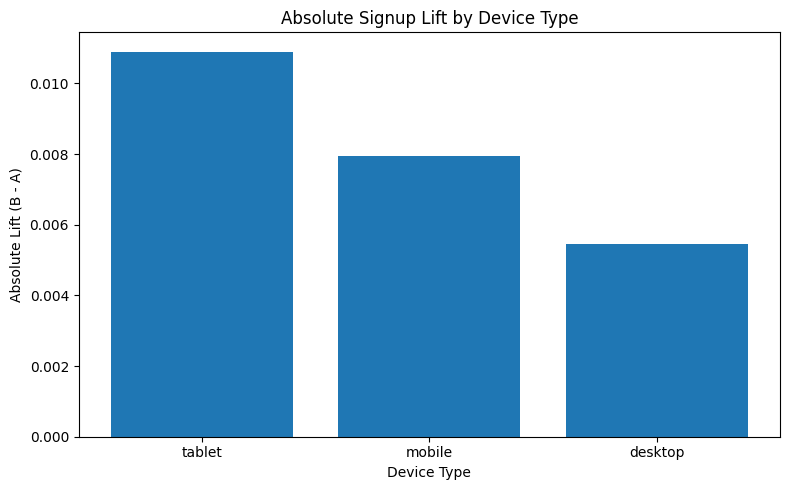

In [16]:
plot_df = device_pivot.sort_values("absolute_lift", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["device_type"], plot_df["absolute_lift"])
plt.title("Absolute Signup Lift by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Absolute Lift (B - A)")
plt.tight_layout()
plt.savefig("../outputs/charts/signup_lift_by_device.png")
plt.show()

In [17]:
user_type_segment = df.groupby(["is_new_user", "variant"]).agg(
    sessions=("session_id", "count"),
    signup_rate=("signed_up", "mean"),
    watch_start_rate=("watch_started", "mean")
).reset_index()

print(user_type_segment)

   is_new_user variant  sessions  signup_rate  watch_start_rate
0            0       a     11230     0.053072          0.133304
1            0       b     11260     0.058171          0.158082
2            1       a     13796     0.066614          0.137721
3            1       b     13714     0.076127          0.155170


In [18]:
user_type_pivot = user_type_segment.pivot(index="is_new_user", columns="variant", values="signup_rate").reset_index()
user_type_pivot.columns = ["is_new_user", "signup_rate_a", "signup_rate_b"]

user_type_pivot["absolute_lift"] = user_type_pivot["signup_rate_b"] - user_type_pivot["signup_rate_a"]
user_type_pivot["relative_lift_pct"] = (user_type_pivot["absolute_lift"] / user_type_pivot["signup_rate_a"]) * 100

print(user_type_pivot)

   is_new_user  signup_rate_a  signup_rate_b  absolute_lift  relative_lift_pct
0            0       0.053072       0.058171       0.005098           9.606524
1            1       0.066614       0.076127       0.009513          14.280999


In [19]:
source_segment = df.groupby(["traffic_source", "variant"]).agg(
    sessions=("session_id", "count"),
    signup_rate=("signed_up", "mean"),
    watch_start_rate=("watch_started", "mean")
).reset_index()

print(source_segment)

  traffic_source variant  sessions  signup_rate  watch_start_rate
0         direct       a      5038     0.059349          0.152243
1         direct       b      5079     0.067533          0.168734
2          email       a      2562     0.072600          0.136612
3          email       b      2514     0.084726          0.157518
4        organic       a      7317     0.058221          0.136258
5        organic       b      7560     0.065079          0.156349
6    paid_search       a      5087     0.059564          0.121486
7    paid_search       b      4850     0.070928          0.149278
8    paid_social       a      5022     0.059936          0.132417
9    paid_social       b      4971     0.061758          0.150674


In [20]:
source_pivot = source_segment.pivot(index="traffic_source", columns="variant", values="signup_rate").reset_index()
source_pivot.columns = ["traffic_source", "signup_rate_a", "signup_rate_b"]

source_pivot["absolute_lift"] = source_pivot["signup_rate_b"] - source_pivot["signup_rate_a"]
source_pivot["relative_lift_pct"] = (source_pivot["absolute_lift"] / source_pivot["signup_rate_a"]) * 100

print(source_pivot.sort_values("absolute_lift", ascending=False))

  traffic_source  signup_rate_a  signup_rate_b  absolute_lift  \
1          email       0.072600       0.084726       0.012126   
3    paid_search       0.059564       0.070928       0.011364   
0         direct       0.059349       0.067533       0.008184   
2        organic       0.058221       0.065079       0.006859   
4    paid_social       0.059936       0.061758       0.001822   

   relative_lift_pct  
1          16.702595  
3          19.079174  
0          13.789682  
2          11.780684  
4           3.039757  


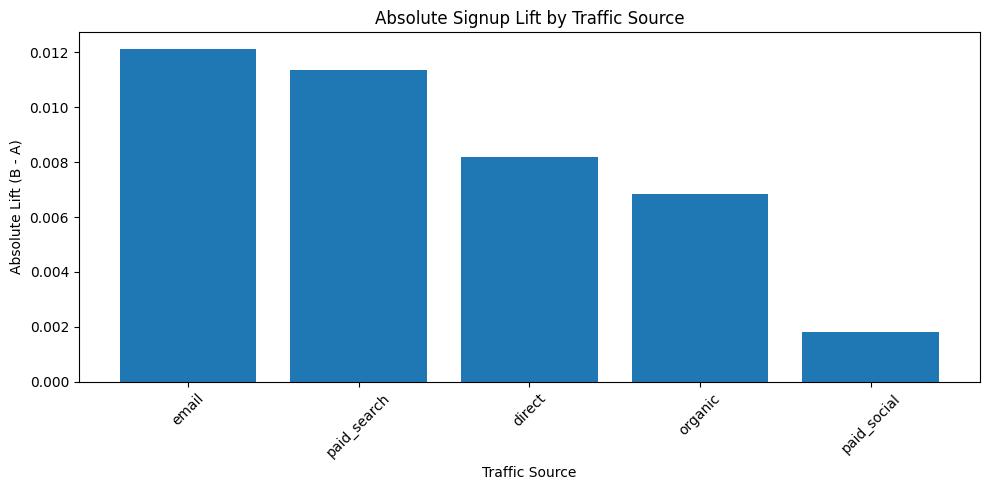

In [21]:
plot_source = source_pivot.sort_values("absolute_lift", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_source["traffic_source"], plot_source["absolute_lift"])
plt.title("Absolute Signup Lift by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Absolute Lift (B - A)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/charts/signup_lift_by_traffic_source.png")
plt.show()

In [22]:
combined_segment = df.groupby(["device_type", "traffic_source", "is_new_user", "variant"]).agg(
    sessions=("session_id", "count"),
    signup_rate=("signed_up", "mean"),
    watch_start_rate=("watch_started", "mean")
).reset_index()

print(combined_segment.head(10))

  device_type traffic_source  is_new_user variant  sessions  signup_rate  \
0     desktop         direct            0       a       671     0.052161   
1     desktop         direct            0       b       692     0.057803   
2     desktop         direct            1       a       848     0.070755   
3     desktop         direct            1       b       794     0.065491   
4     desktop          email            0       a       324     0.070988   
5     desktop          email            0       b       341     0.079179   
6     desktop          email            1       a       408     0.061275   
7     desktop          email            1       b       413     0.106538   
8     desktop        organic            0       a       975     0.042051   
9     desktop        organic            0       b      1010     0.057426   

   watch_start_rate  
0          0.159463  
1          0.171965  
2          0.160377  
3          0.159950  
4          0.148148  
5          0.202346  
6        

In [23]:
combined_pivot = combined_segment.pivot_table(
    index=["device_type", "traffic_source", "is_new_user"],
    columns="variant",
    values="signup_rate"
).reset_index()

combined_pivot.columns = ["device_type", "traffic_source", "is_new_user", "signup_rate_a", "signup_rate_b"]

combined_counts = df.groupby(["device_type", "traffic_source", "is_new_user"]).size().reset_index(name="sessions")
combined_pivot = combined_pivot.merge(combined_counts, on=["device_type", "traffic_source", "is_new_user"], how="left")

combined_pivot["absolute_lift"] = combined_pivot["signup_rate_b"] - combined_pivot["signup_rate_a"]
combined_pivot["relative_lift_pct"] = (combined_pivot["absolute_lift"] / combined_pivot["signup_rate_a"]) * 100

top_segments = combined_pivot[combined_pivot["sessions"] >= 300].sort_values("absolute_lift", ascending=False)

print(top_segments.head(15))

   device_type traffic_source  is_new_user  signup_rate_a  signup_rate_b  \
27      tablet    paid_search            1       0.045802       0.092150   
3      desktop          email            1       0.061275       0.106538   
21      tablet         direct            1       0.041985       0.083056   
20      tablet         direct            0       0.035874       0.066390   
28      tablet    paid_social            0       0.031250       0.057971   
17      mobile    paid_search            1       0.066038       0.089140   
15      mobile        organic            1       0.059340       0.075286   
4      desktop        organic            0       0.042051       0.057426   
10      mobile         direct            0       0.047198       0.059035   
29      tablet    paid_social            1       0.060606       0.071146   
2      desktop          email            0       0.070988       0.079179   
5      desktop        organic            1       0.061396       0.069413   
7      deskt

In [24]:
device_pivot.to_csv("../outputs/reports/device_uplift_table.csv", index=False)
user_type_pivot.to_csv("../outputs/reports/user_type_uplift_table.csv", index=False)
source_pivot.to_csv("../outputs/reports/source_uplift_table.csv", index=False)
top_segments.to_csv("../outputs/reports/top_segment_uplift_table.csv", index=False)

print("Saved segment uplift tables to ../outputs/reports/")

Saved segment uplift tables to ../outputs/reports/


## Segment-level interpretation

The treatment effect was not uniform across all users.

Key observations:
- Device-level uplift showed which platforms responded most strongly to Variant B.
- New users and returning users responded differently, suggesting onboarding sensitivity.
- Traffic-source analysis highlighted where the treatment had the highest conversion impact.
- Combined segment analysis identified high-opportunity cohorts for targeted rollout.

These findings suggest that experiment rollout decisions should consider segment-specific performance rather than relying only on aggregate uplift.

In [25]:
mobile_a = df[(df["device_type"] == "mobile") & (df["variant"] == "a")]
mobile_b = df[(df["device_type"] == "mobile") & (df["variant"] == "b")]

mobile_conversions = np.array([
    mobile_a["signed_up"].sum(),
    mobile_b["signed_up"].sum()
])

mobile_samples = np.array([
    mobile_a["signed_up"].count(),
    mobile_b["signed_up"].count()
])

z_mobile, p_mobile = proportions_ztest(mobile_conversions, mobile_samples)

print("Mobile segment signup rate A:", round(mobile_a["signed_up"].mean(), 4))
print("Mobile segment signup rate B:", round(mobile_b["signed_up"].mean(), 4))
print("Mobile segment p-value:", round(p_mobile, 6))

Mobile segment signup rate A: 0.0615
Mobile segment signup rate B: 0.0695
Mobile segment p-value: 0.00538
